In [1]:
from mymodels import squeezenet1_1, train, kCV, test_error
from dataUtils import *
from sklearn.model_selection import KFold
from torch.utils.data import Subset
from torch import nn,optim,save,load
import matplotlib.pyplot as plt

device = 'cuda'

In [3]:
model = squeezenet1_1(dropout=0)
model.to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.02848174232146005)
epochs = 15
dataset = make_train_val_set()
all_loss = kCV(5,dataset,model,loss_fn,optimizer,epochs=epochs,batch_size=32)
save(model.state_dict(), 'models/squeeze_net.pth')

FOLD 0
EPOCH 1
	train loss:	 0.0429951615099396
	val. loss:	 0.04246930629014969
EPOCH 2
	train loss:	 0.04013735116744528
	val. loss:	 0.042102716863155365
EPOCH 3
	train loss:	 0.039021685405881426
	val. loss:	 0.04263633497059345
EPOCH 4
	train loss:	 0.03722193697467446
	val. loss:	 0.03793870665132999
EPOCH 5
	train loss:	 0.03682518766584749
	val. loss:	 0.03892741195857525
EPOCH 6
	train loss:	 0.03677525339477068
	val. loss:	 0.03938636064529419
EPOCH 7
	train loss:	 0.035877381261362105
	val. loss:	 0.04073808699846268
EPOCH 8
	train loss:	 0.036394948767003964
	val. loss:	 0.037138820588588715
EPOCH 9
	train loss:	 0.03680317473540805
	val. loss:	 0.03819553755223751
EPOCH 10
	train loss:	 0.03653915864130368
	val. loss:	 0.0391829813271761
EPOCH 11
	train loss:	 0.037179269428764074
	val. loss:	 0.03784939728677273
EPOCH 12
	train loss:	 0.03738824319930709
	val. loss:	 0.038390368819236756
EPOCH 13
	train loss:	 0.03626122221122591
	val. loss:	 0.03839071251451969
EPOCH 14


In [4]:
import json
filename = 'results/squeezenet.json'
with open(filename, 'w') as fp:
        json.dump(all_loss, fp)

/home/aislab/.local/lib/python3.8/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


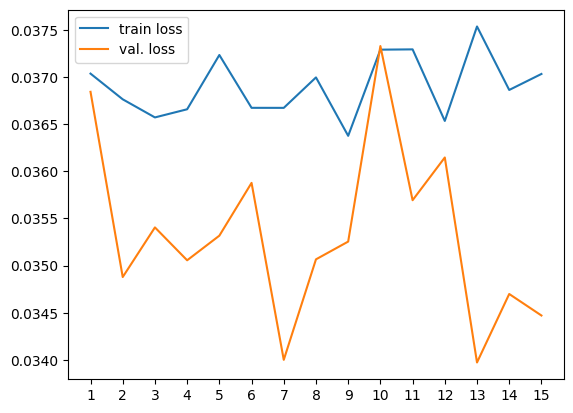

In [2]:
net = squeezenet1_1()
net.load_state_dict(load('models/squeeze_net.pth',weights_only=True))
all_loss = load_json('results/squeezenet.json')
plt.subplots()
epochs = len(all_loss['all-loss'][0]['train'])
plt.plot(range(1,epochs+1),all_loss['all-loss'][-1]['train'],label='train loss')
plt.plot(range(1,epochs+1),all_loss['all-loss'][-1]['validation'],label='val. loss')
plt.xticks(range(1,epochs+1))
plt.legend()
plt.show()

In [3]:
cv = all_loss['CV-loss']
test = test_error(net,make_test_set())
validation = all_loss['all-loss'][-1]['validation'][-1]
train = all_loss['all-loss'][-1]['train'][-1]

print(f'train: {train}\nvalid.: {validation}\ntest: {test}\ncv: {cv}')

train: 0.03703076214225469
valid.: 0.034470676258206365
test: 0.0384948955535696
cv: 0.03681971260160207
